In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# -----------------------------
# 1. Load data
# -----------------------------
df = pd.read_csv("data/test_train_val_sets/cardio_baseline_train.csv")

# features onlywith open("models/baseline_models/cardio_xgb_baseline_model.pkl", "rb") as f:

X_test = df.drop(columns=["cardio", "stratify"])
y_test = df["cardio"]

# -----------------------------
# 2. Load trained model
# -----------------------------
model = joblib.load("models/baseline_models/cardio_xgb_baseline_model.pkl")   # change path if needed

# optional: predictions
y_pred = model.predict(X_test)



Correlation matrix:
             gender  height  weight  ap_hi  ap_lo  cholesterol   gluc  smoke   alco  active  age_years
gender        1.000   0.526   0.160  0.065  0.066       -0.034 -0.021  0.340  0.173   0.005     -0.027
height        0.526   1.000   0.306  0.015  0.029       -0.056 -0.023  0.200  0.102  -0.011     -0.092
weight        0.160   0.306   1.000  0.272  0.250        0.143  0.107  0.067  0.067  -0.013      0.051
ap_hi         0.065   0.015   0.272  1.000  0.729        0.194  0.092  0.027  0.032   0.002      0.209
ap_lo         0.066   0.029   0.250  0.729  1.000        0.161  0.076  0.024  0.034   0.005      0.153
cholesterol  -0.034  -0.056   0.143  0.194  0.161        1.000  0.448  0.010  0.037   0.014      0.158
gluc         -0.021  -0.023   0.107  0.092  0.076        0.448  1.000 -0.007  0.010  -0.008      0.099
smoke         0.340   0.200   0.067  0.027  0.024        0.010 -0.007  1.000  0.342   0.025     -0.049
alco          0.173   0.102   0.067  0.032  0.034   

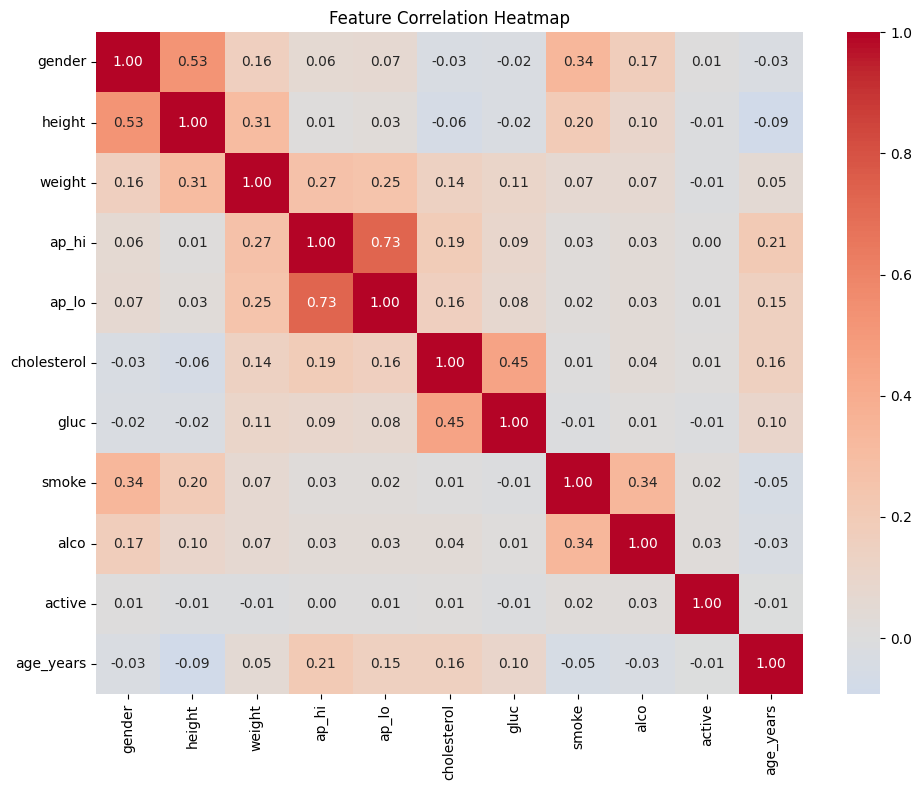

In [9]:
# -----------------------------
# 3. Correlation matrix
# -----------------------------
corr_matrix = X_test.corr(numeric_only=True)

print("\nCorrelation matrix:")
print(corr_matrix.round(3).to_string())

# -----------------------------
# 4. Full heatmap
# -----------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [10]:

# -----------------------------
# 5. Strong correlations only
# -----------------------------
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
corr_pairs["Abs_Correlation"] = corr_pairs["Correlation"].abs()

strong_corrs = corr_pairs[corr_pairs["Abs_Correlation"] >= 0.30].sort_values(
    "Abs_Correlation", ascending=False
)

print("\nStrong correlations (|r| >= 0.30):")
print(strong_corrs.round(3).to_string(index=False))




Strong correlations (|r| >= 0.30):
  Feature_1 Feature_2  Correlation  Abs_Correlation
      ap_hi     ap_lo        0.729            0.729
     gender    height        0.526            0.526
cholesterol      gluc        0.448            0.448
      smoke      alco        0.342            0.342
     gender     smoke        0.340            0.340
     height    weight        0.306            0.306


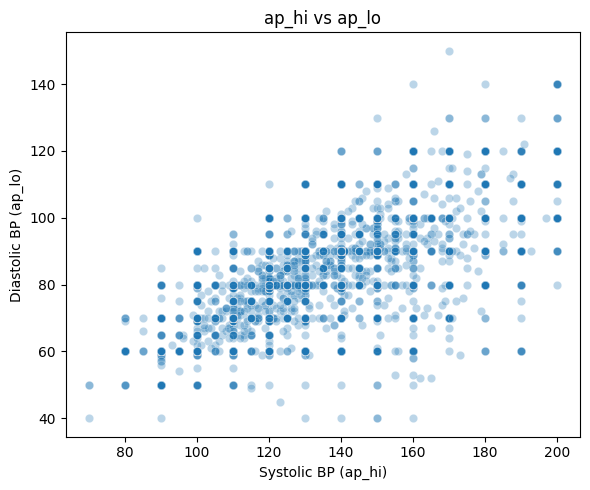

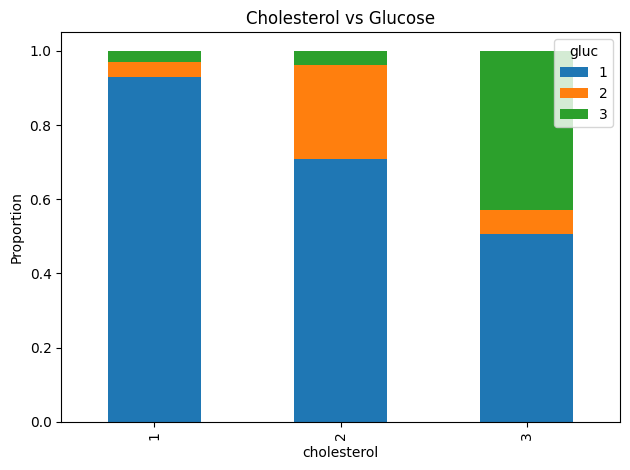

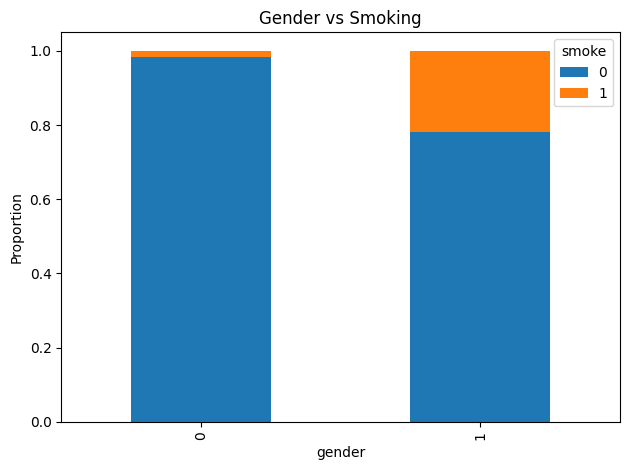

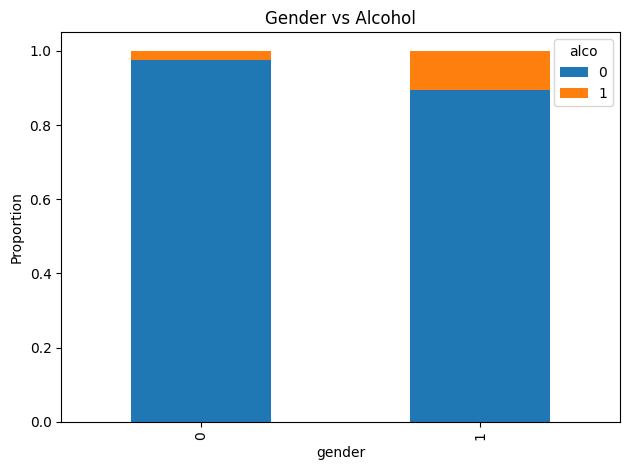

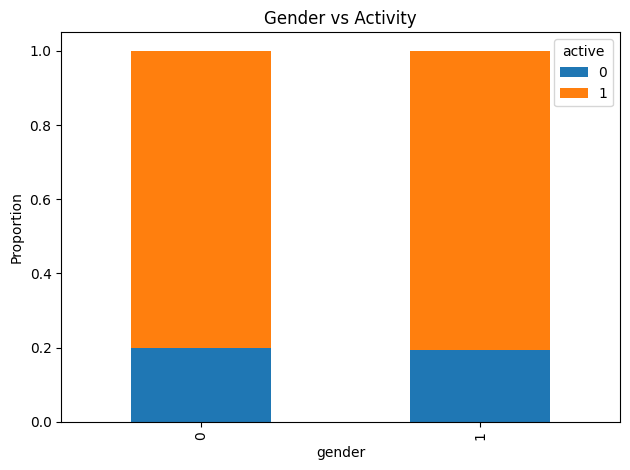

In [11]:
# -----------------------------
# 6. Scatter plots for top pairs : only continuous vals
# -----------------------------
top_pairs = strong_corrs.head(6)

# --- Scatter: ap_hi vs ap_lo ---
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="ap_hi", y="ap_lo", alpha=0.3)
plt.title("ap_hi vs ap_lo")
plt.xlabel("Systolic BP (ap_hi)")
plt.ylabel("Diastolic BP (ap_lo)")
plt.tight_layout()
plt.show()


# # --- Scatter: height vs weight ---
# plt.figure(figsize=(6,5))
# sns.scatterplot(data=df, x="height", y="weight", alpha=0.3)
# plt.title("Height vs Weight")
# plt.xlabel("Height (cm)")
# plt.ylabel("Weight (kg)")
# plt.tight_layout()
# plt.show()


# --- Scatter: height vs weight ---
# plt.figure(figsize=(6,5))
# sns.scatterplot(data=df, x="height", y="age_years", alpha=0.3)
# plt.title("WHAT PERSON IS 120cm???")
# plt.xlabel("Height (cm)")
# plt.ylabel("Age (years)")
# plt.tight_layout()
# plt.show()

# --- Stacked Bar plots for categorical / ordinal --- #
# --- Cholesterol vs Glucose ---
ct = pd.crosstab(df["cholesterol"], df["gluc"], normalize="index")
ct.plot(kind="bar", stacked=True)
plt.title("Cholesterol vs Glucose")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()


# --- Gender vs Smoke ---
ct = pd.crosstab(df["gender"], df["smoke"], normalize="index")
ct.plot(kind="bar", stacked=True)
plt.title("Gender vs Smoking")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()


# --- Gender vs Alcohol ---
ct = pd.crosstab(df["gender"], df["alco"], normalize="index")
ct.plot(kind="bar", stacked=True)
plt.title("Gender vs Alcohol")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()


# --- Gender vs Activity ---
ct = pd.crosstab(df["gender"], df["active"], normalize="index")
ct.plot(kind="bar", stacked=True)
plt.title("Gender vs Activity")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()



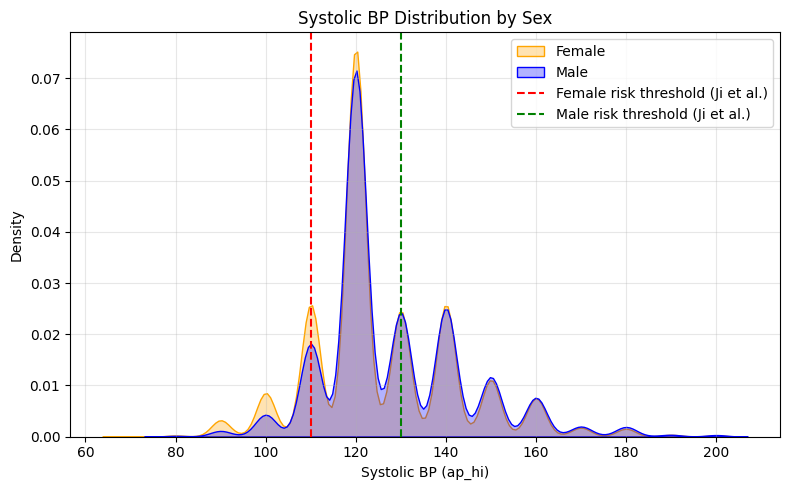

In [12]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df["gender"] == 0], x="ap_hi", 
            label="Female", fill=True, alpha=0.3, color="orange")
sns.kdeplot(data=df[df["gender"] == 1], x="ap_hi", 
            label="Male", fill=True, alpha=0.3, color="blue")
plt.axvline(x=110, color='red', linestyle='--', linewidth=1.5,
            label="Female risk threshold (Ji et al.)")
plt.axvline(x=130, color='green', linestyle='--', linewidth=1.5,
            label="Male risk threshold (Ji et al.)")
plt.title("Systolic BP Distribution by Sex")
plt.xlabel("Systolic BP (ap_hi)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Feature correlation with cardio outcome:
ap_hi          0.429
ap_lo          0.339
age_years      0.239
cholesterol    0.226
weight         0.180
gluc           0.095
active        -0.036
smoke         -0.019
height        -0.018
alco          -0.013
gender         0.006


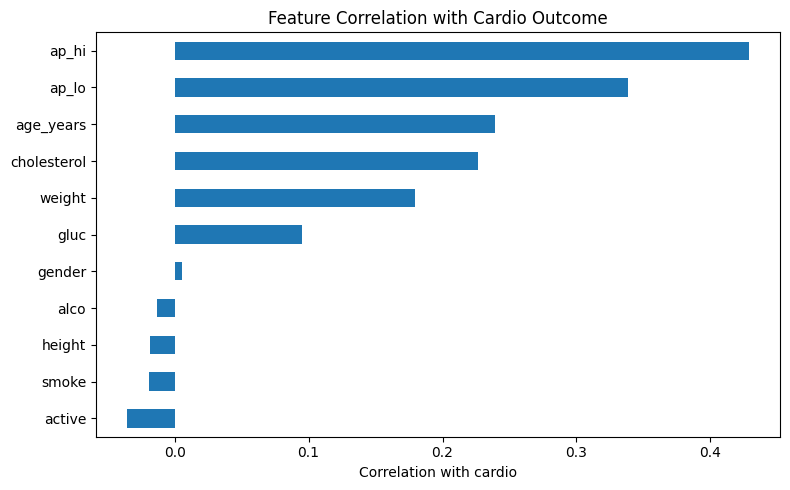

In [13]:
# -----------------------------
# 7. Correlation with outcome
# -----------------------------
feature_target_corr = df.drop(columns=["stratify"]).corr(numeric_only=True)["cardio"].drop("cardio")
feature_target_corr = feature_target_corr.sort_values(key=np.abs, ascending=False)

print("\nFeature correlation with cardio outcome:")
print(feature_target_corr.round(3).to_string())

plt.figure(figsize=(8, 5))
feature_target_corr.sort_values().plot(kind="barh")
plt.title("Feature Correlation with Cardio Outcome")
plt.xlabel("Correlation with cardio")
plt.tight_layout()
plt.show()

In [14]:
data  = pd.read_csv("data/processed/cardio_baseline_clean.csv")
# print how many smokers and have cardio ratioed on gender
smokers = data[data['smoke'] == 1]
table = pd.crosstab(smokers['gender'], smokers['cardio'])
print(table)

table2 = pd.crosstab(
    [data['gender'], data['smoke']],
    data['cardio']
)

print(table2)

cardio     0     1
gender            
0        416   370
1       2782  2448
cardio            0      1
gender smoke              
0      0      22041  21500
       1        416    370
1      0       9157   9463
       1       2782   2448
